<a href="https://colab.research.google.com/github/RaviduSenavirathna/Sinhala-Word-Recognizer/blob/main/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt


model = tf.keras.models.load_model("/content/drive/MyDrive/Sinhala-CNN/sinhala_convnext_canny.keras")
CLASS_NAMES = ['ක', 'ග', 'ත', 'න', 'ප', 'ම', 'ර', 'ල', 'ස', 'හ']   # IMPORTANT: use SAME order as training
IMG_SIZE = 128
SEGMENTED_DIR = "/content/drive/MyDrive/Sinhala-CNN/output"


# Define the image preprocessing function
def img_processing(img):
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    # Apply Otsu's thresholding to convert to binary image
    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    return thresh

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
def preprocess_for_model(img_path):
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError(f"Cannot read image: {img_path}")

    # ---- YOUR preprocessing ----
    img = img_processing(img)

    # resize to model input
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # normalize
    img = img.astype("float32") / 255.0

    # GRAY → RGB (IMPORTANT)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # add batch dimension
    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 3)

    return img

In [4]:
def predict_letter(img_path):
    x = preprocess_for_model(img_path)

    preds = model.predict(x, verbose=0)[0]
    class_id = int(np.argmax(preds))
    confidence = float(preds[class_id])

    return CLASS_NAMES[class_id], confidence



In [5]:
results = []

for file in sorted(os.listdir(SEGMENTED_DIR)):
    if not file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    path = os.path.join(SEGMENTED_DIR, file)
    label, conf = predict_letter(path)
    results.append((file, label, conf))

    print(f"{file}  →  {label}  ({conf:.2f})")


char_1.png  →  ස  (0.82)
char_2.png  →  ර  (0.60)
char_3.png  →  ල  (1.00)


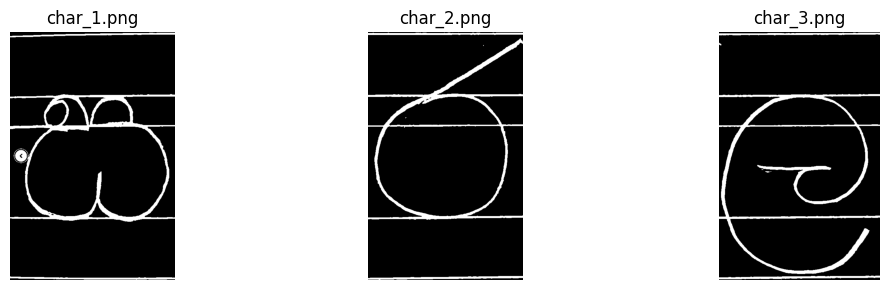

In [6]:
plt.figure(figsize=(12, 3))

for i, (file, label, conf) in enumerate(results):
    img = cv2.imread(
        os.path.join(SEGMENTED_DIR, file),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(1, len(results), i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3523 (\N{SINHALA LETTER DANTAJA SAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.print_figure(bytes_io, **kw)


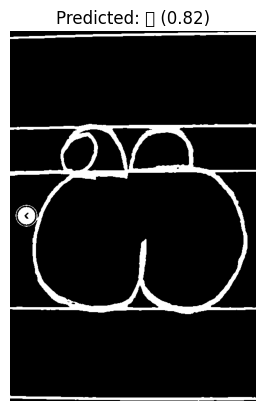

Predicted: ස (0.82)


In [7]:
# predict using specific image
test_img = "/content/drive/MyDrive/Sinhala-CNN/output/char_1.png"

label, conf = predict_letter(test_img)

img = cv2.imread(test_img, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title(f"Predicted: {label} ({conf:.2f})")
plt.axis("off")
plt.show()

print(f"Predicted: {label} ({conf:.2f})")
